In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv
import sys
sys.path.append("../..")

from serving.utils_image import *

from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial.distance import cdist
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier

load_dotenv()



True

In [ ]:
DIR_PATH = Path("..")

MODEL_NAME = "random_forest_v1.1"

IMG_FOLDER_PATH=os.getenv("IMG_FOLDER_PATH")

random_state = 42

# webcam is static for the first few handred images
sample_images = 111

# features
FIREPLACE_POLY = np.array([ 
    [270, 205],
    [373, 217],
    [370, 270],
    [270, 255]
], dtype=np.int32)

OUTPUT_SIZE = 256
N_BANDS = 3
HOT_PIXEL_V_THRESHOLD = 200
N_CLUSTER = 7

# Clustering

In [3]:
# Load
all_files = sorted([
    os.path.join(IMG_FOLDER_PATH, f)
    for f in os.listdir(IMG_FOLDER_PATH)
    if f.lower().endswith((".jpg", ".png", ".jpeg")) and not f.lower().endswith(("1.jpg", "1.png", "1.jpeg"))
])

image_paths = all_files[:sample_images]
print(f"Processing: {len(image_paths)} images")
print(f"last image: {Path(image_paths[-1]).name}")


Processing: 111 images
last image: screenshot_2026-01-02_00-00-00.jpg


In [4]:
# Extract features and keep paths
X = []
paths = []
for path in image_paths:
    img = load_image(path)
    warped = warp_polygon_to_square(img, FIREPLACE_POLY, OUTPUT_SIZE)
    feats = extract_features(warped, N_BANDS, HOT_PIXEL_V_THRESHOLD)
    X.append(feats)
    paths.append(path)

X = np.vstack(X)
print("Feature matrix shape:", X.shape)

Feature matrix shape: (111, 18)


In [5]:
df_X = pd.DataFrame(X)
# df_X.describe()

In [6]:
# KMeans clustering
kmeans = KMeans(n_clusters=N_CLUSTER, random_state=random_state)
kmeans.fit(X)
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

# Find 5 closest images to each centroid
distances = cdist(X, centroids)

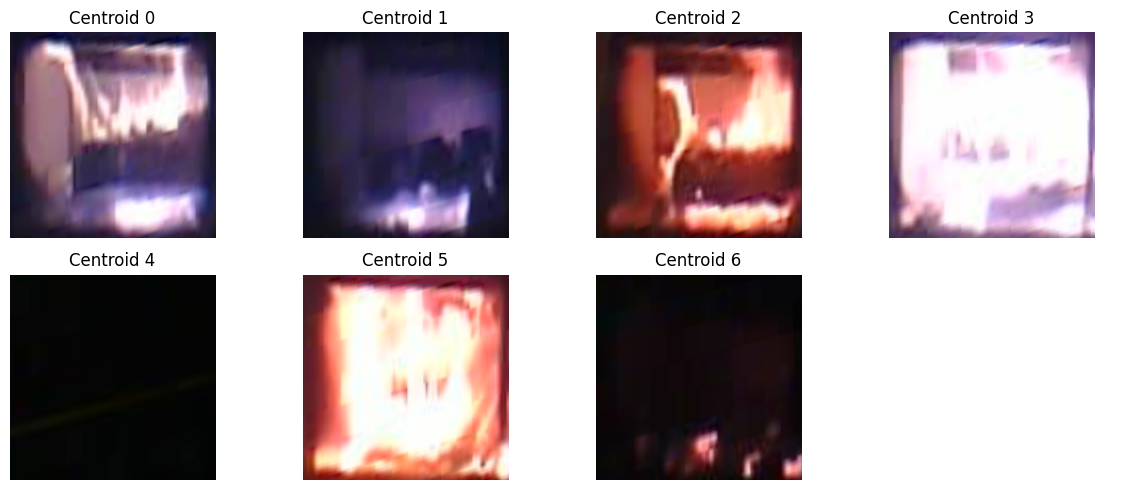

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(12, 5))
axes = axes.flatten()
plot_idx = 0

for i in range(N_CLUSTER):
    idx_sorted = np.argsort(distances[:, i])[:1]
    for idx in idx_sorted:
        img = load_image(paths[idx])
        warped = warp_polygon_to_square(img, FIREPLACE_POLY, OUTPUT_SIZE)

        ax = axes[plot_idx]
        ax.imshow(warped)
        ax.set_title(f"Centroid {i}")
        ax.axis("off")

        plot_idx += 1

for j in range(plot_idx, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [8]:
cluster_to_label = {
    0: "medium flames",
    1: "small flames",
    2: "medium flames",
    3: "large flames",
    4: "black",
    5: "large flames",
    6: "embers",
}

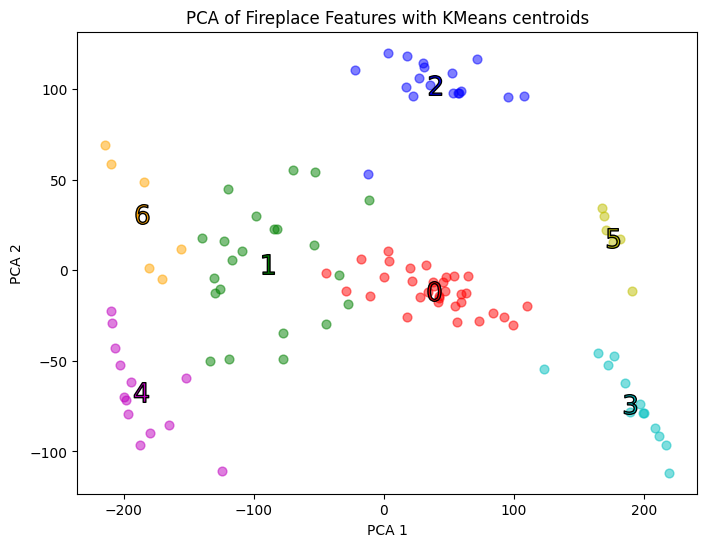

In [9]:
# PCA scatter plot with centroids
pca = PCA(n_components=2, random_state=random_state)
X_2d = pca.fit_transform(X)
centroids_2d = pca.transform(centroids)

plt.figure(figsize=(8,6))
colors = ["r", "g", "b", "c", "m", "y", "orange", "purple", "brown", "pink"]
for k in range(N_CLUSTER):
    mask = labels == k
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1], c=colors[k], alpha=0.5, s=40)
    plt.scatter(
        centroids_2d[k, 0],
        centroids_2d[k, 1],
        c=colors[k],
        edgecolor="k",
        s=200,
        marker=f"${k}$"
    )
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("PCA of Fireplace Features with KMeans centroids")
plt.show()

# Train Classifier

In [10]:
y = np.array([cluster_to_label[l] for l in labels])

clf = RandomForestClassifier(n_estimators=200, random_state=random_state)
clf.fit(X, y)

# Save model
joblib.dump(clf, DIR_PATH /'models'/ f'{MODEL_NAME}.joblib')

['../models/todelete.joblib']

Predicted category: medium flames
Prediction probabilities:
  black: 0.000
  embers: 0.000
  large flames: 0.460
  medium flames: 0.535
  small flames: 0.005


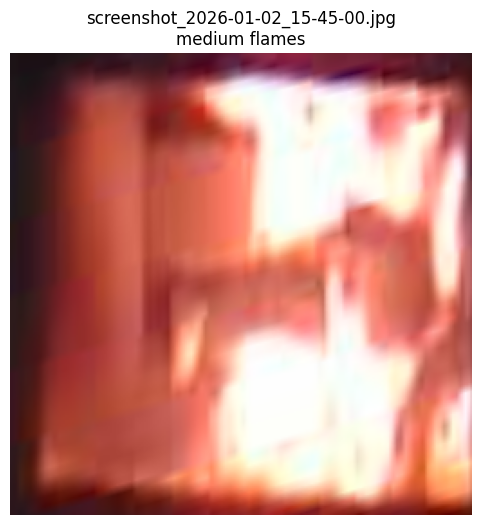

In [11]:
test_image_n = 300
test_image_path = Path(all_files[test_image_n])
test_image = test_image_path.name

# Load, warp, extract features
img_new = load_image(test_image_path)
warped_new = warp_polygon_to_square(img_new, FIREPLACE_POLY, OUTPUT_SIZE)
features_new = extract_features(warped_new, N_BANDS, HOT_PIXEL_V_THRESHOLD).reshape(1, -1)

# Predict label
pred_label = clf.predict(features_new)[0]
pred_proba = clf.predict_proba(features_new)[0]

print(f"Predicted category: {pred_label}")
print("Prediction probabilities:")
for cat, prob in zip(clf.classes_, pred_proba):
    print(f"  {cat}: {prob:.3f}")

plot_image(warped_new, title=test_image + f"\n{pred_label}")
